Fetching historical data for TSLA...


/tmp/ipykernel_7963/1096534183.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start="2023-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed



--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): $12.49
R² Score (Variance Explained): 0.9243



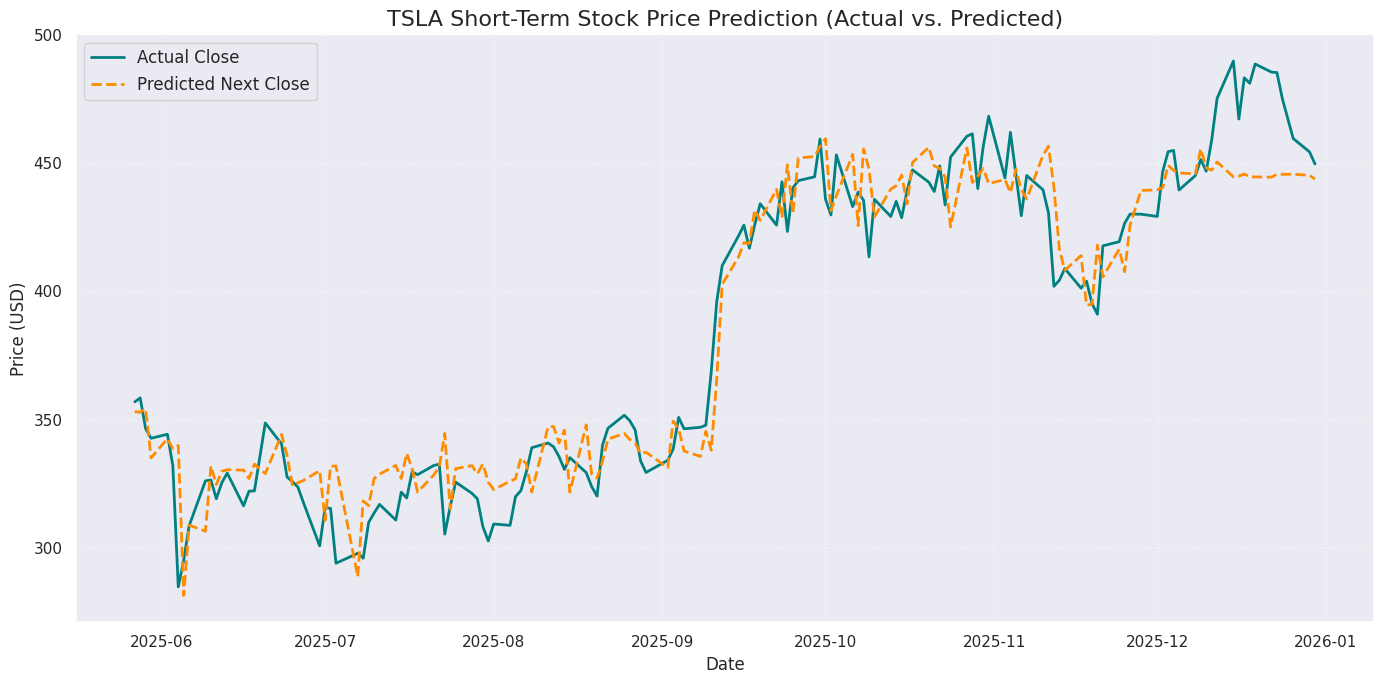

/tmp/ipykernel_7963/1096534183.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette="viridis")


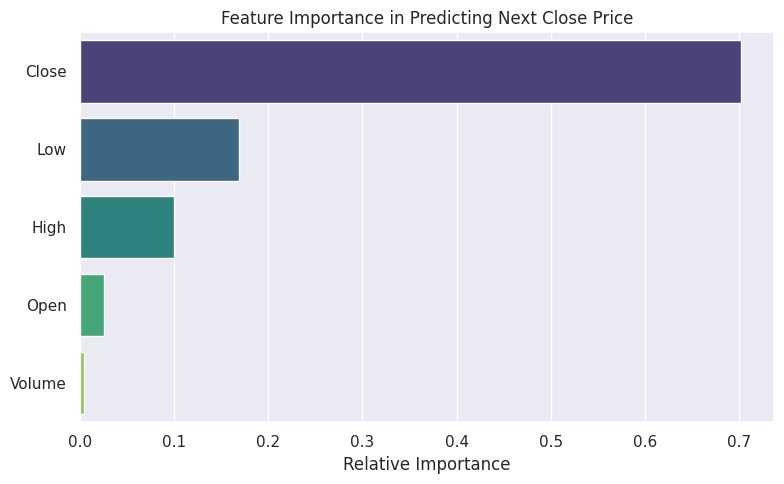

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import yfinance as yf

# =====================================================================
# 1. Fetching Historical Stock Data via yfinance
# =====================================================================
ticker = "TSLA"  # You can change this to AAPL, MSFT, etc.
print(f"Fetching historical data for {ticker}...")

# Fetch 3 years of daily historical data
stock_data = yf.download(ticker, start="2023-01-01", end="2026-01-01")

# Clean up multi-level columns if returned by yfinance
if isinstance(stock_data.columns, pd.MultiIndex):
    stock_data.columns = stock_data.columns.get_level_values(0)

# =====================================================================
# 2. Feature Engineering: Shifting the Target
# =====================================================================
# We want to use Today's Open, High, Low, Close, and Volume...
# ...to predict TOMORROW's Close price.
stock_data["Next_Close"] = stock_data["Close"].shift(-1)

# Drop the last row because it won't have a "Next Day" target value
stock_data = stock_data.dropna()

# Define Features (X) and Target (y)
features = ["Open", "High", "Low", "Close", "Volume"]
X = stock_data[features]
y = stock_data["Next_Close"]

# =====================================================================
# 3. Splitting and Training the Model
# =====================================================================
# For time-series, a chronological split is ideal, but for standard
# regression evaluation, a shuffle-split or train_test_split works well.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Instantiate and train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# =====================================================================
# 4. Evaluating the Model
# =====================================================================
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R² Score (Variance Explained): {r2:.4f}\n")

# =====================================================================
# 5. Plotting Actual vs. Predicted Prices
# =====================================================================
# Convert test targets and predictions to a cleaner DataFrame for plotting
test_dates = y_test.index
results_df = pd.DataFrame(
    {"Actual": y_test, "Predicted": y_pred}, index=test_dates
)

sns.set_theme(style="darkgrid")
plt.figure(figsize=(14, 7))

# Line plot comparing actual vs predicted over time
plt.plot(results_df.index, results_df["Actual"], label="Actual Close", color="teal", lw=2)
plt.plot(
    results_df.index,
    results_df["Predicted"],
    label="Predicted Next Close",
    color="darkorange",
    linestyle="--",
    lw=2,
)

plt.title(
    f"{ticker} Short-Term Stock Price Prediction (Actual vs. Predicted)",
    fontsize=16,
)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Bonus Plot: Feature Importance ---
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette="viridis")
plt.title("Feature Importance in Predicting Next Close Price")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()